The following example shows how to train a model. Get a list of training data csv file in the selected folder. Lessons learned so far:
- Training result is very sensitive to normalization. The normalization approach based on mean and variance does not work very well. Still need to manually set mean and variance.
- t-sne plot of adapter trace is an important flag of training result. 
- h net does not have to descent because phi net training strives to make it rise, while h net training itself tries to lower the loss
- Increase the h training frequency to fight against rising h 
- Increase alpha to push domain info to adapter
- Increase number of features to minimize MSE loss.
- ocassional small spike in cross entropy loss is possibly a sign that phi net become further domain invariant and may not be bad.
- at the late stage of training while both mse loss and cross entropy loss converge. May need to train h net every step to refine the optimization direction.
- Do not need to select the model at the end epoch. Select the epoch when the loss is reasonably low and stable. 
- RMS is a good indicator because it matches the least square form of loss function
- When the residual force is small, e.g. training disturbance force compensated by BEMT, disturbance normalization should scale up the label for better learning. 

Existing problem:
- The more classes, the harder to train. The difficulty comes from instability of loss_f and loss_c. alpha is hard to tune.
- t-sne gets worse as epoch grows and the cross entropy loss remains the same. 

In [1]:
import os
import matplotlib.pyplot as plt

import training_manager

current_dir = os.getcwd()
# training_subfolder = "wind_near_wall_bemt_fitting"
# training_subfolder = "wind_near_wall_bemt_fitting_validation"
# training_subfolder = "wind_near_wall_bemt_fitting_hover"
# training_subfolder = "nf_training_back2back"
# training_subfolder = "wind_free_space_training"
training_subfolder = "wind_free_space_training_in_house_sim"
# validation_subfolder = "nf_validation_back2back"
# validation_subfolder = "wind_near_wall_bemt_fitting_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_far_from_wall_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_validation_sinusoidal"
# validation_subfolder = "wind_near_wall_bemt_fitting_hover_validation"
# validation_subfolder = "wind_near_wall_bemt_fitting_hover_far_from_wall_validation"
# validation_subfolder = "wind_free_space_validation"
validation_subfolder = "wind_free_space_validation_in_house_sim"

def generate_data_list(subfolder):
    """
    Generate a list of data files in the specified subfolder.
    """
    folder_path = os.path.join(os.path.dirname(current_dir), "data", "training", subfolder)
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Filter out files that do not end with .csv
    file_names = [f for f in file_names if f.endswith('.csv')]
    # add subfolder to the file names
    data_list = [os.path.join(subfolder, f) for f in file_names]
    return data_list

data_list = generate_data_list(training_subfolder)
print("Training Data List:")
for data in data_list:
    print(data)

validation_list = generate_data_list(validation_subfolder)
print("\nValidation Data List:")
for data in validation_list:
    print(data)

path1 = os.path.join(training_subfolder, "input_label_map_disturbance_force_label.yaml")

Training Data List:
wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_xn1_0_y0_0_z0_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_xn1_0_y0_0_z3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_xn1_0_y0_0_z5_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_xn1_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
wind_free_space_training_in_house_sim\test_wind_near_wall_xn1_0_y0_0_zn5_0_d100_4_train_no_

- Make sure the input_label_map_disturbance_force_label.yaml is in the selected folder. This yaml defines which fields are model inputs and which fields are data labels. 
- Make sure the column_map.yaml is in the selected folder. This yaml maps data fields to the corresponding column in the csv files. This file can be auto-generated by `Simulation\simulation\training_data_user_guide.ipynb`
- If this is the first time to train on this data. The script will normalize the data and save the normalization parameters into a file.

Setting up data factory...
Loading normalization params file from
..\data\training\wind_free_space_training_in_house_sim\normalization_params.yaml
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z0_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z3_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_z5_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn3_0_d100_4_train_no_bemt.csv
Using 2002 samples from the dataset for training from source file: wind_free_space_training_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn5_0_d100_4_train_no_bemt.csv
Using 2002 samples from th

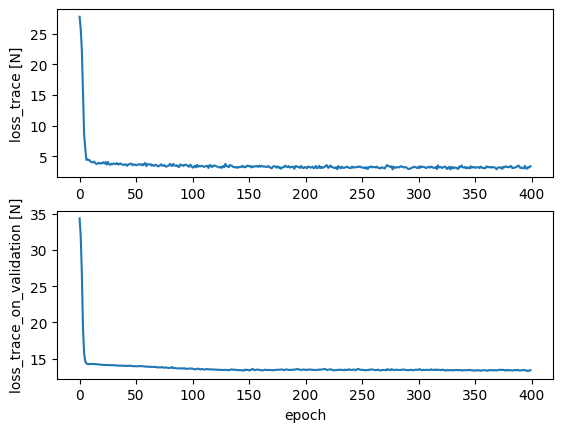

In [2]:
# use the data from previous section to train the model

factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.SIMPLE_NET)
manager = factory.make_training_pipeline()
manager.set_up(
    training_data_menu=data_list,
    # training_data_menu=data_list[:4],    # use small data list for quick testing
    validation_data_menu=validation_list[:],
    input_label_map_file=path1,
    can_inspect_data=False
)
manager.train()

plt.show()  

Inspect data in the data list.

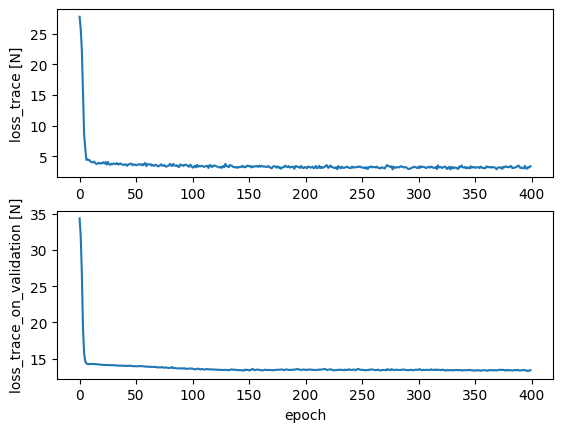

In [3]:
# trainer_instance.inspect_data(data_list[:2])
manager.show_result_only()

After training, we can save the model in the following way.

In [4]:
model_name = training_subfolder
manager.save_model(model_name)

Model saved to model\wind_free_space_training_in_house_sim.pth


Test the model using the test set.

test Data List:
wind_free_space_validation_in_house_sim\test_wind_near_wall_x0_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_x0_0_y0_0_z4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_x0_0_y0_0_zn4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_xn2_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_xn2_0_y0_0_z4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_xn2_0_y0_0_zn1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_xn2_0_y0_0_zn4_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_wind_near_wall_xn5_0_y0_0_z1_0_d1_4_validation_no_bemt.csv
wind_free_space_validation_in_house_sim\test_win

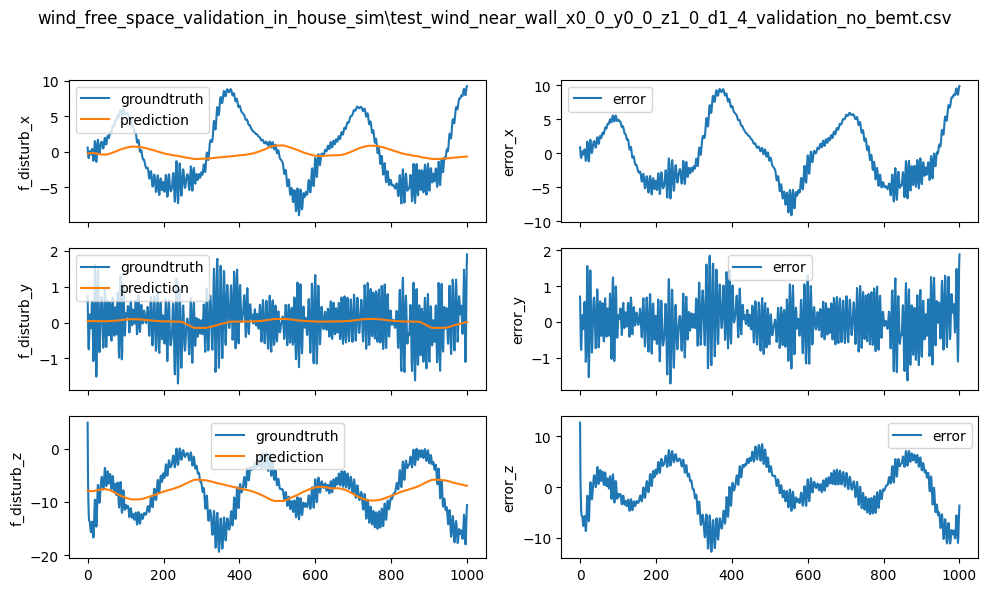

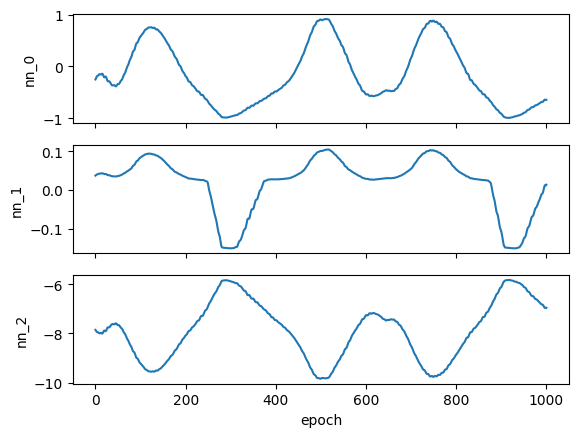

prediction: tensor([[-0.4396,  0.0350, -7.4067],
        [-0.4642,  0.0335, -7.3742],
        [-0.4514,  0.0343, -7.3988],
        ...,
        [-0.7804, -0.0733, -6.4842],
        [-0.7830, -0.0733, -6.4783],
        [-0.7811, -0.0713, -6.4874]])


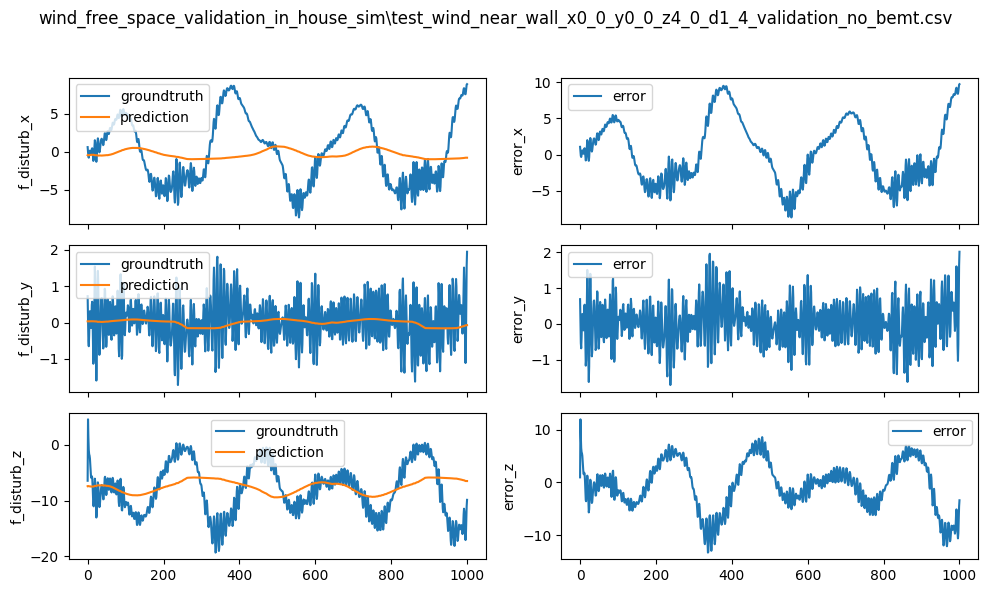

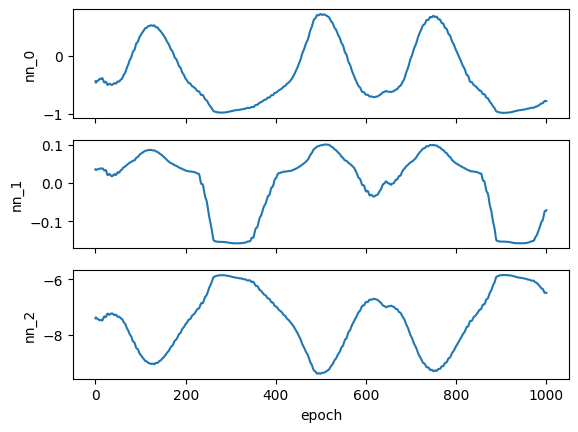

prediction: tensor([[-0.1315,  0.0366, -8.1503],
        [-0.0955,  0.0384, -8.2008],
        [-0.0664,  0.0398, -8.2424],
        ...,
        [-0.5450,  0.0266, -7.2919],
        [-0.5490,  0.0263, -7.2838],
        [-0.5471,  0.0262, -7.2915]])


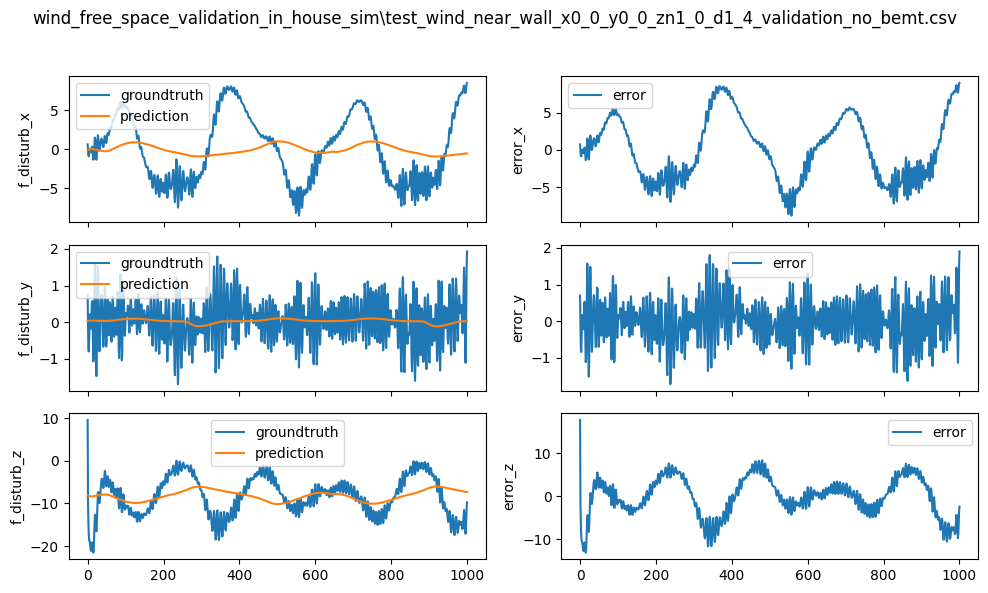

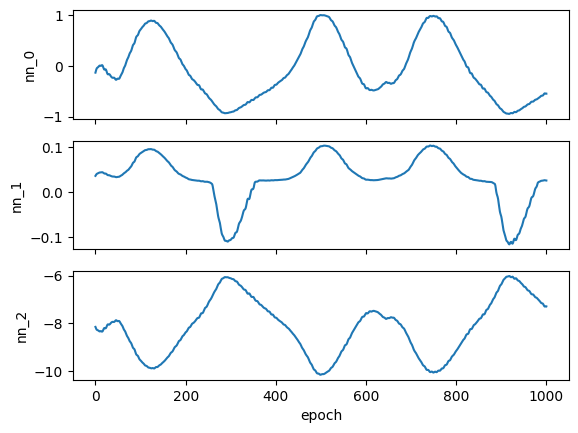

prediction: tensor([[ 0.0531,  0.0359, -8.5953],
        [ 0.1218,  0.0396, -8.6873],
        [ 0.1559,  0.0414, -8.7353],
        ...,
        [-0.3753,  0.0258, -7.7746],
        [-0.3807,  0.0256, -7.7663],
        [-0.3781,  0.0255, -7.7738]])


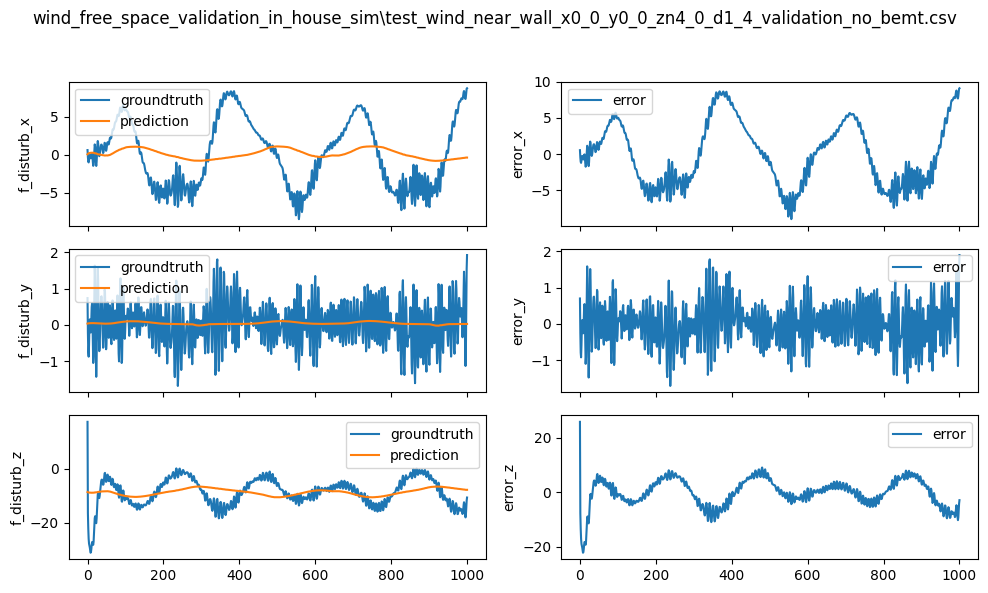

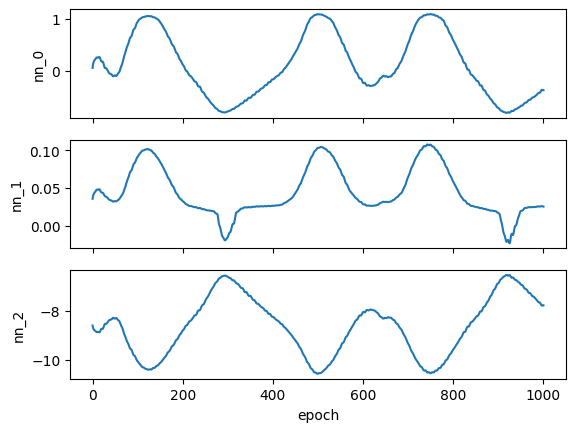

prediction: tensor([[-0.1082,  0.0431, -8.0852],
        [-0.0869,  0.0440, -8.1192],
        [-0.0609,  0.0452, -8.1584],
        ...,
        [-0.5845,  0.0230, -7.0988],
        [-0.5888,  0.0226, -7.0902],
        [-0.5869,  0.0243, -7.0980]])


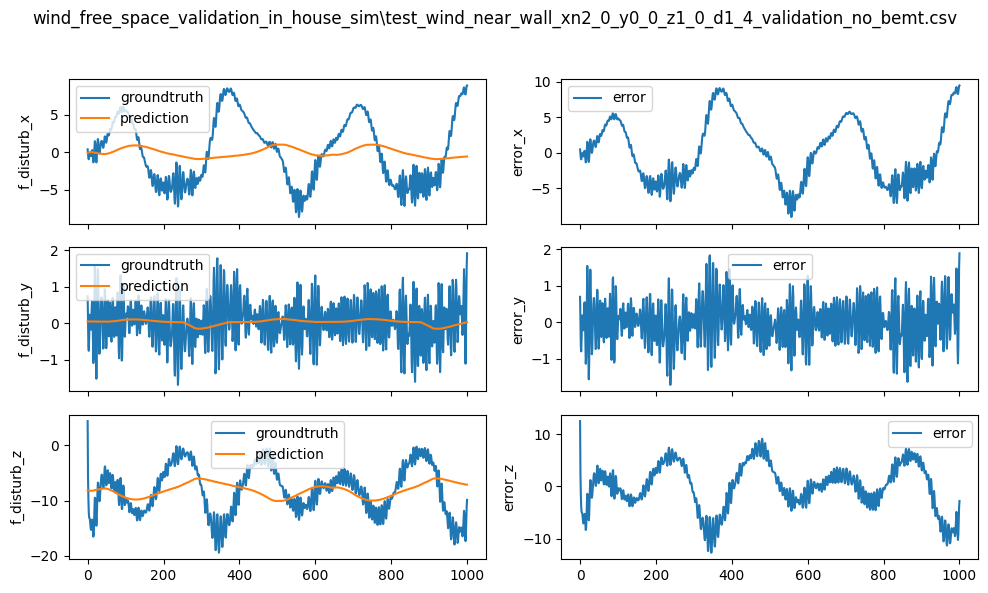

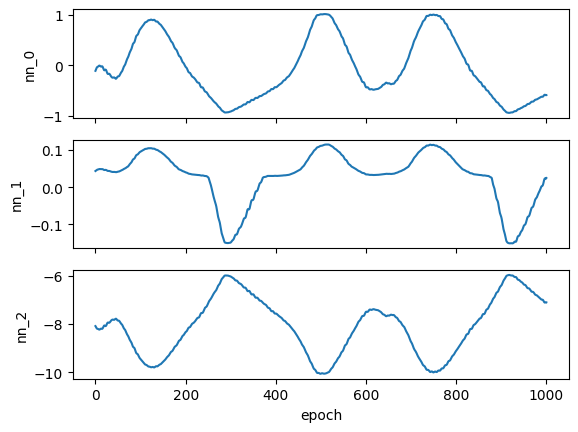

prediction: tensor([[-0.2942,  0.0426, -7.6388],
        [-0.3232,  0.0411, -7.6065],
        [-0.3078,  0.0419, -7.6315],
        ...,
        [-0.7155, -0.0599, -6.6446],
        [-0.7188, -0.0600, -6.6381],
        [-0.7168, -0.0580, -6.6467]])


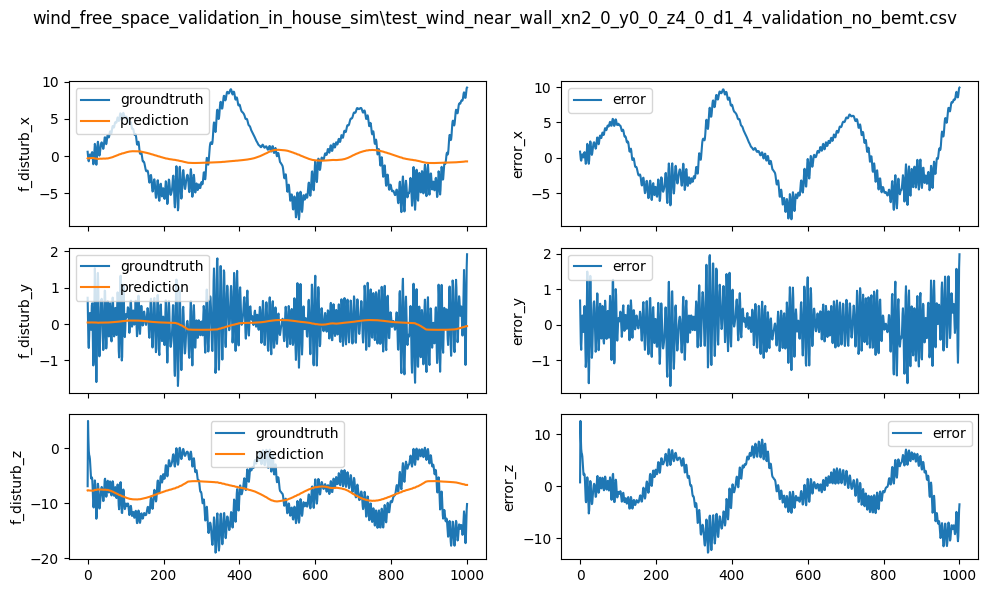

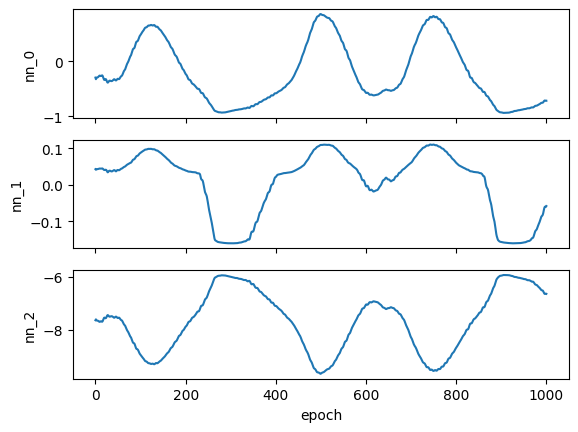

prediction: tensor([[ 0.0150,  0.0427, -8.3823],
        [ 0.0523,  0.0445, -8.4364],
        [ 0.0852,  0.0460, -8.4852],
        ...,
        [-0.4831,  0.0296, -7.4281],
        [-0.4879,  0.0293, -7.4181],
        [-0.4864,  0.0292, -7.4246]])


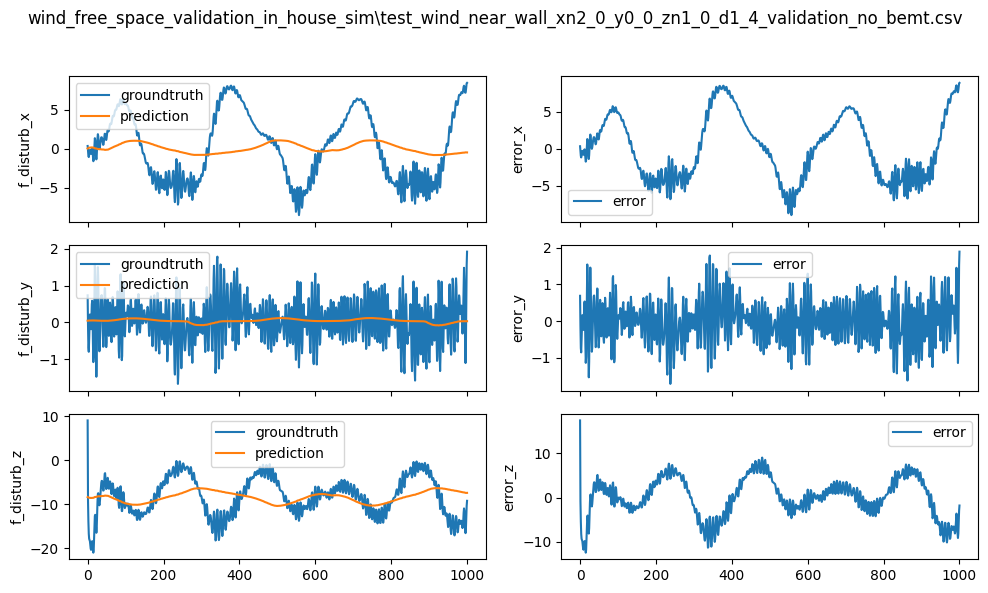

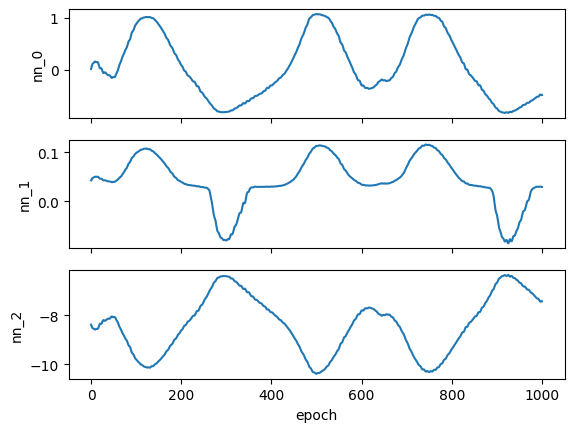

prediction: tensor([[ 0.1996,  0.0420, -8.8273],
        [ 0.2703,  0.0469, -8.9239],
        [ 0.3082,  0.0497, -8.9790],
        ...,
        [-0.2964,  0.0291, -7.9007],
        [-0.3020,  0.0288, -7.8924],
        [-0.3000,  0.0287, -7.8990]])


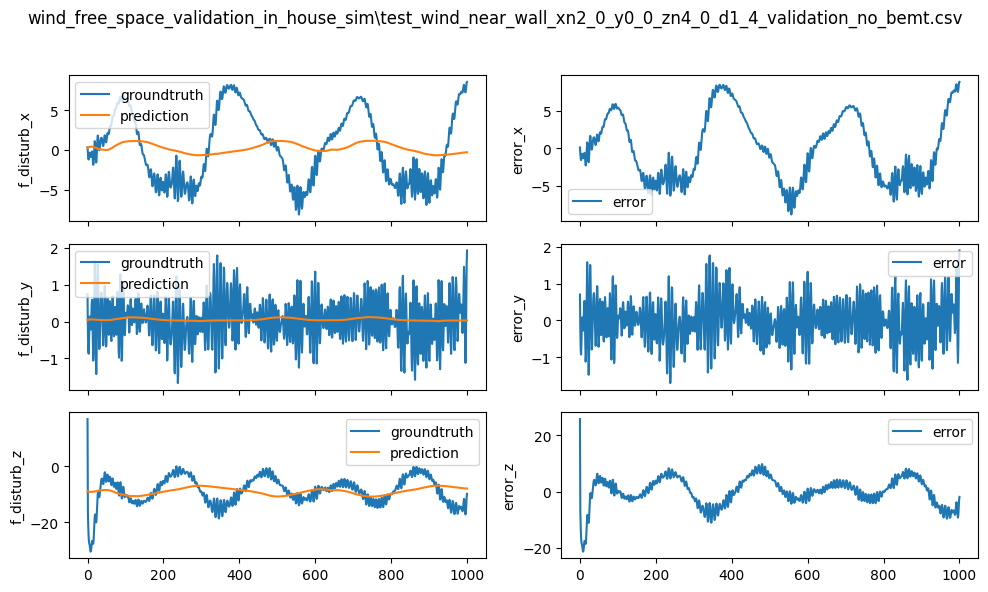

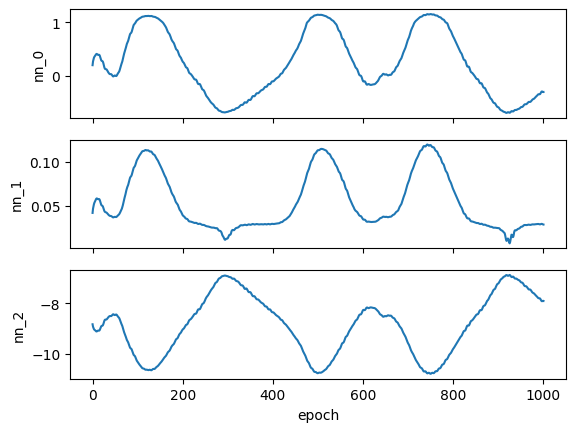

prediction: tensor([[ 0.1092,  0.0522, -8.4300],
        [ 0.1191,  0.0522, -8.4529],
        [ 0.1501,  0.0536, -8.5011],
        ...,
        [-0.4975,  0.0313, -7.2874],
        [-0.5022,  0.0310, -7.2782],
        [-0.5012,  0.0311, -7.2842]])


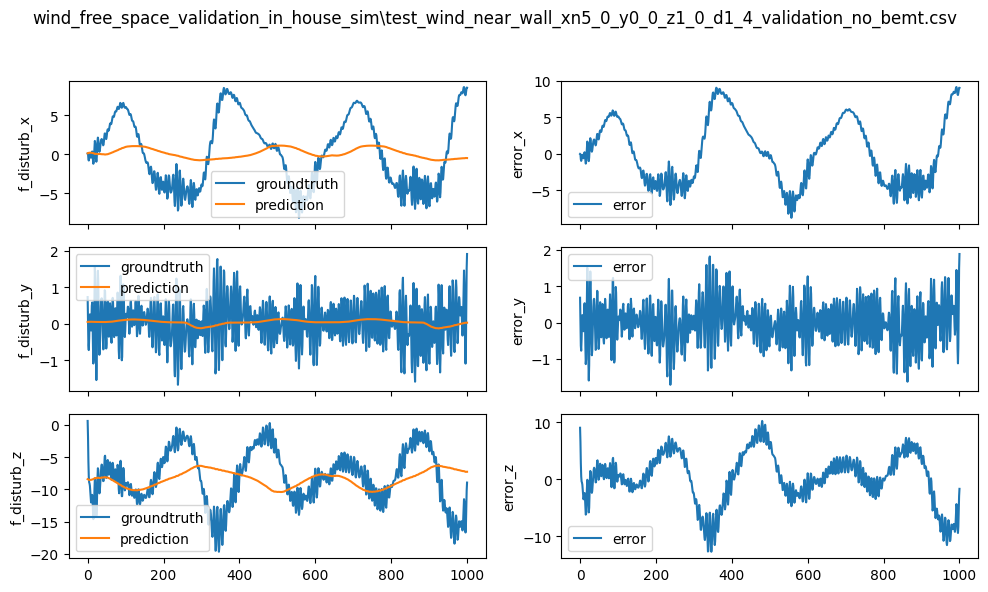

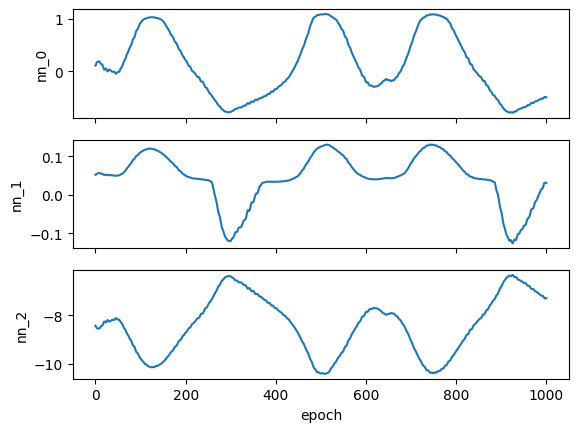

prediction: tensor([[-0.0763,  0.0528, -7.9840],
        [-0.1112,  0.0504, -7.9459],
        [-0.0970,  0.0509, -7.9703],
        ...,
        [-0.6248, -0.0437, -6.8580],
        [-0.6292, -0.0441, -6.8484],
        [-0.6291, -0.0427, -6.8518]])


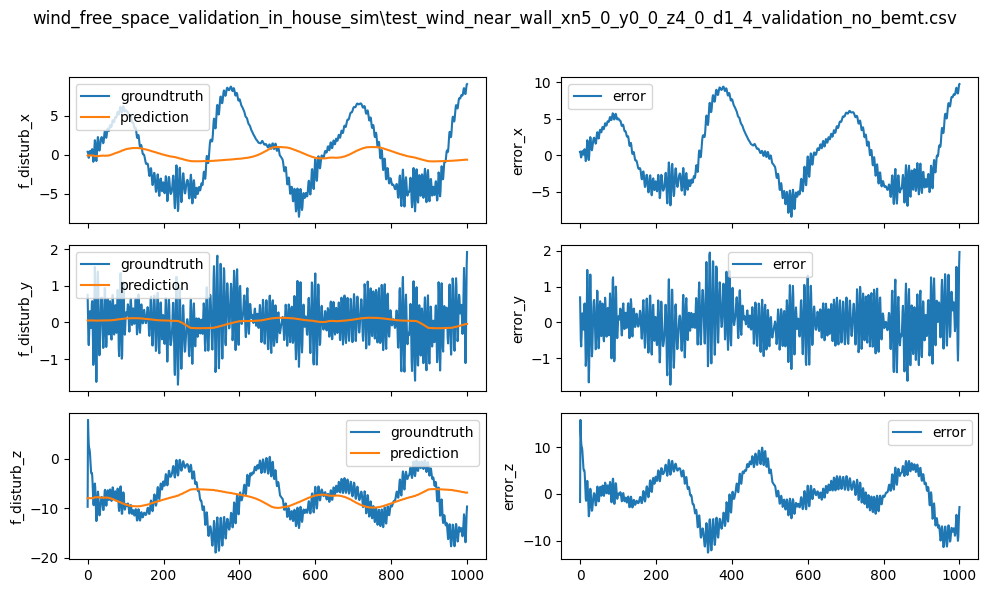

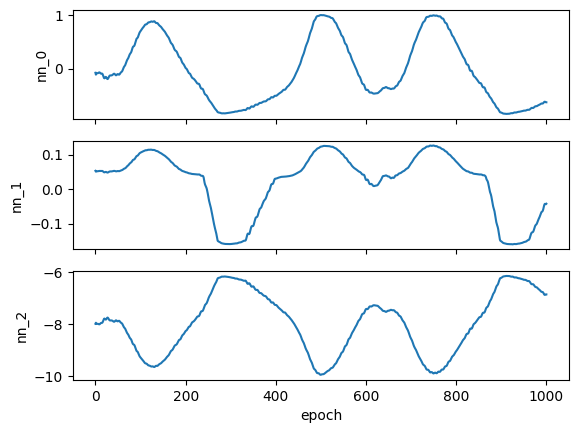

prediction: tensor([[ 0.2327,  0.0529, -8.7270],
        [ 0.2676,  0.0553, -8.7823],
        [ 0.3032,  0.0580, -8.8372],
        ...,
        [-0.3738,  0.0346, -7.6184],
        [-0.3803,  0.0343, -7.6087],
        [-0.3791,  0.0341, -7.6141]])


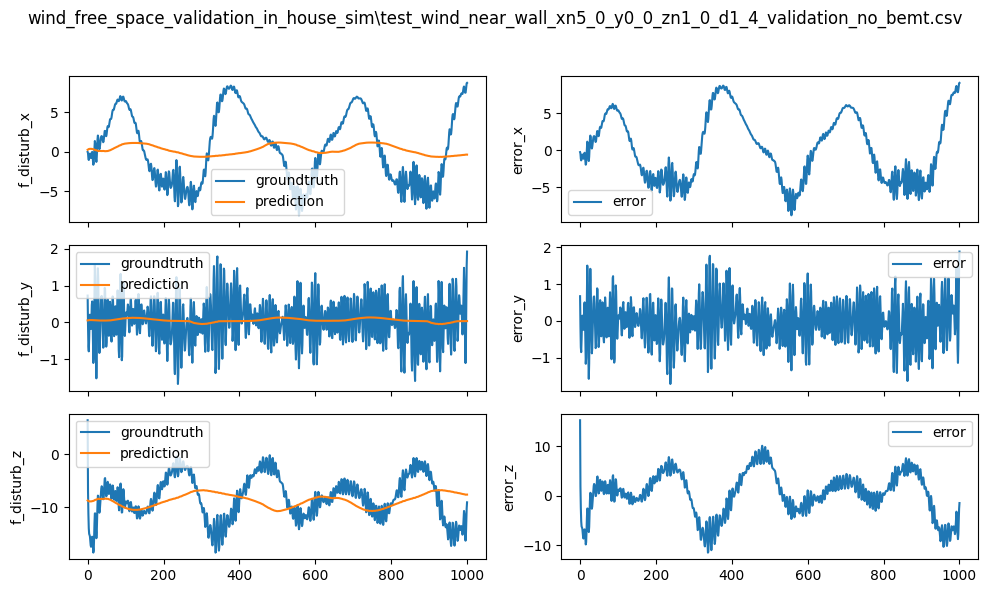

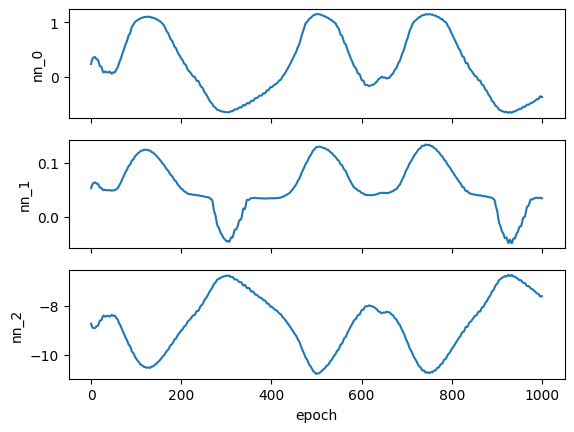

prediction: tensor([[ 0.4186,  0.0563, -9.1737],
        [ 0.4954,  0.0631, -9.2826],
        [ 0.5404,  0.0669, -9.3506],
        ...,
        [-0.1743,  0.0341, -8.0967],
        [-0.1804,  0.0338, -8.0877],
        [-0.1784,  0.0336, -8.0946]])


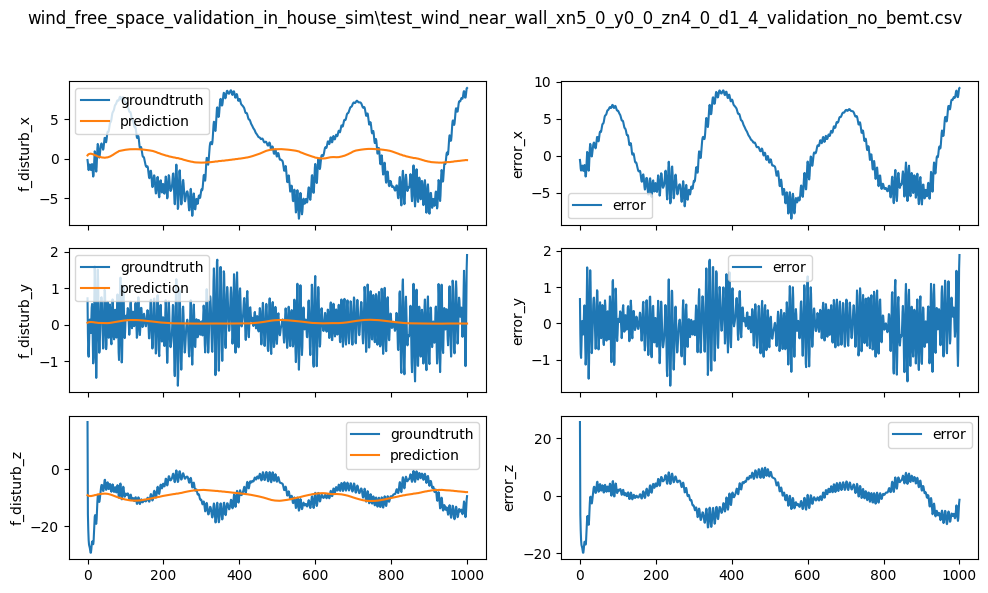

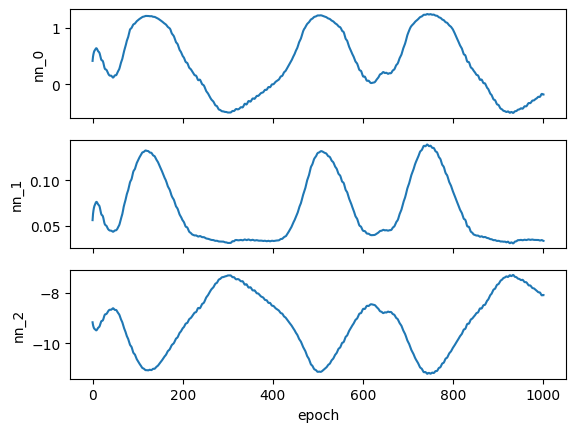

average rms for dim 0: 4.361453228365291
average rms for dim 1: 0.5847239821112228
average rms for dim 2: 4.5624842308655875


c:\Users\jiexu\Documents\workspace\aerial_robot_testbed\learning\validator.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


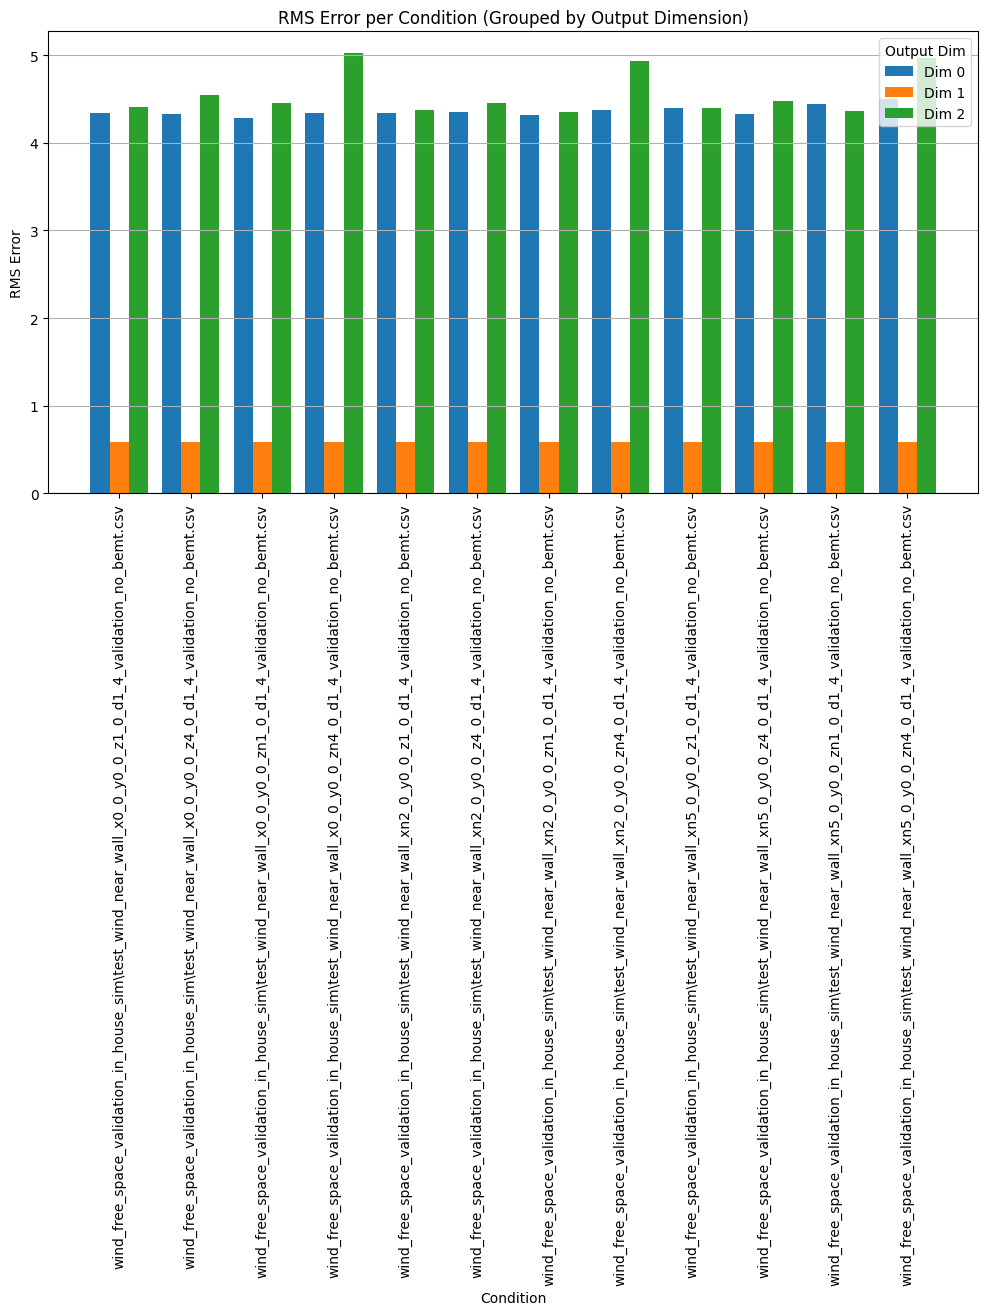

overall average mse after train: 40.24310315060824 before train: 107.27328530261138
average mse for dim 0: after train: 19.025638065933375 before train: 19.085607046942673
average mse for dim 1: after train: 0.34191370882322797 before train: 0.3426925333617201
average mse for dim 2: after train: 20.87555137585164 before train: 87.84498572230699


c:\Users\jiexu\Documents\workspace\aerial_robot_testbed\learning\validator.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


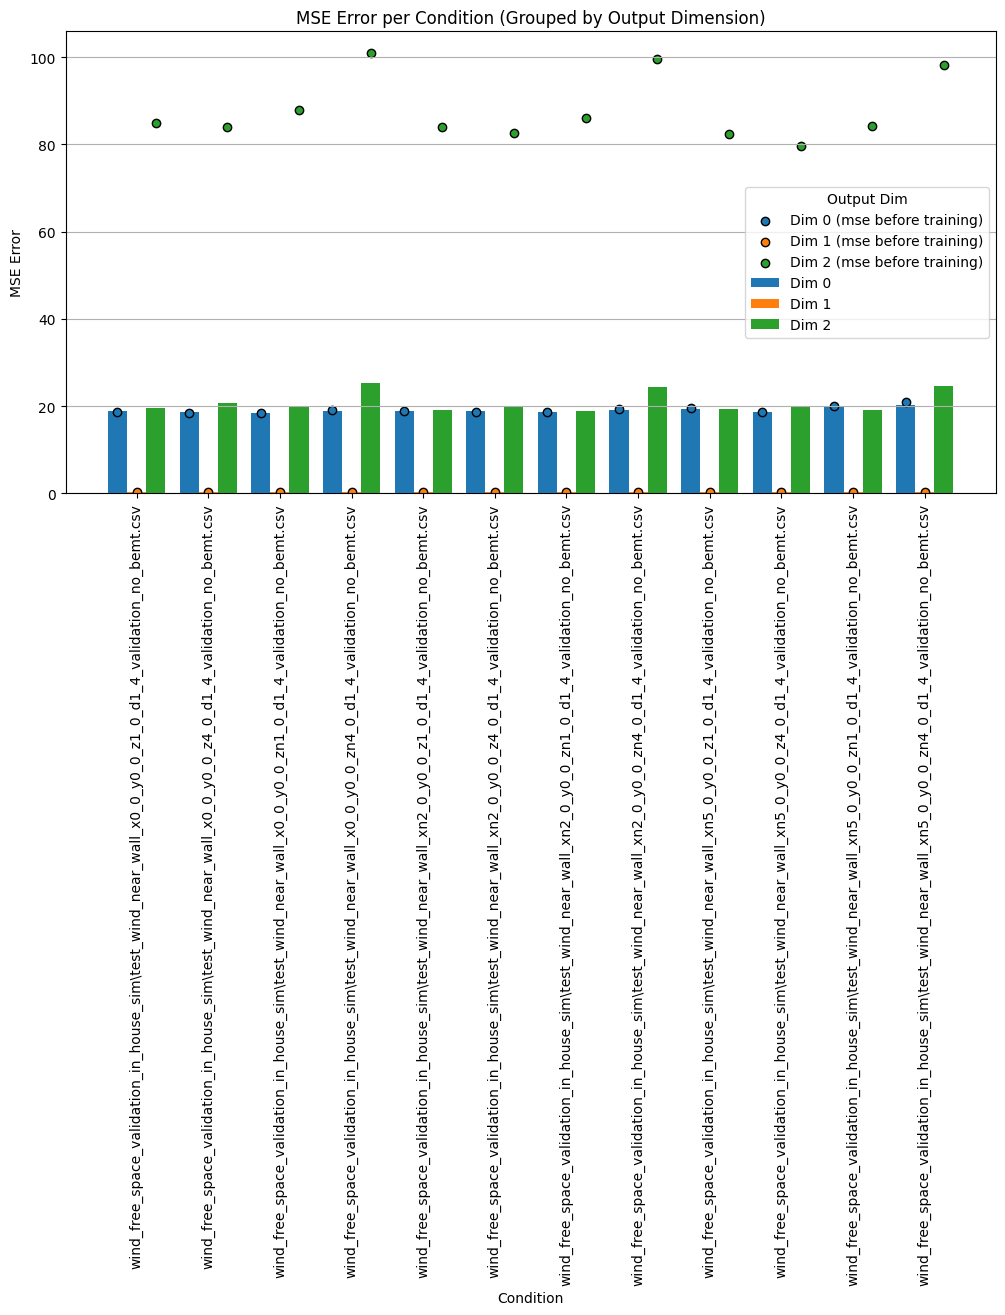

In [5]:
%matplotlib inline
# %matplotlib tk
model_name = training_subfolder

subfolder = validation_subfolder
# subfolder = "wind_near_wall_bemt_fitting_validation"
# subfolder = "nf_validation_back2back"
data_list = generate_data_list(subfolder)
print("test Data List:")
for data in data_list:
    print(data)

# debug
# data_list = data_list[:1]  # use small data list for quick testing
# factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.SIMPLE_NET)
manager = factory.make_test_pipeline()

manager.set_up(
    data_menu=data_list,
    input_label_map_file=path1,
    model_name=model_name
)

# make a new trainer to replicate the above setup, just to allow verify_model to work
manager.test()
plt.show()  
